In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

road_df = pd.read_csv("Maantie.csv")
municipality_df = pd.read_csv("Kunta.csv")
beds_df = pd.read_csv("Vuoteet.csv")

road_df["City"] = road_df["Alue"].str.strip()
municipality_df["City"] = municipality_df["namefin"].str.strip()
beds_df["City"] = beds_df["Kunta"].str.strip()

df = municipality_df.merge(road_df, on="City", how="left")
df = df.merge(beds_df, on="City", how="left")


In [3]:
# road density
df["road_density"] = df["Tiepituus"] / df["landarea"]

# tourism density (cleaned some data)
df["Liikkeet, lkm 2025*"] = df["Liikkeet, lkm 2025*"].replace(".", np.nan)
df["Liikkeet, lkm 2025*"] = pd.to_numeric(df["Liikkeet, lkm 2025*"])
df["tourism_density"] = df["Liikkeet, lkm 2025*"] / df["landarea"]

df[["City", "road_density", "tourism_density"]]

,City,road_density,tourism_density
0,Vimpeli,0.386436,NaN
1,Paimio,0.536283,NaN
2,Lapinlahti,0.426653,NaN
3,Hailuoto,0.189679,NaN
4,Karstula,0.291969,NaN
...,...,...,...
303,Enonkoski,0.312129,NaN
304,Pello,0.193889,0.002877
305,Hirvensalmi,0.386939,NaN
306,Kihniö,0.344355,NaN


## Summary Statistics

In [ ]:
road_dens = df["road_density"]
print("Road Density")
print(f"Mean: {road_dens.mean()}")
print(f"Median: {road_dens.median()}")
print(f"Min: {road_dens.min()}")
print(f"Max: {road_dens.max()}")
print(f"Standard deviation: {road_dens.std()}")


Road Density
Mean: 0.3645508483783112
Median: 0.36409126568358124
Min: 0.04611722470578919
Max: 0.7991475759190197
Standard deviation: 0.12721855393158296


In [ ]:
tourism_dens = df["tourism_density"]
print("Tourism Density")
print(f"Mean: {tourism_dens.mean()}")
print(f"Median: {tourism_dens.median()}")
print(f"Min: {tourism_dens.min()}")
print(f"Max: {tourism_dens.max()}")
print(f"Standard deviation: {tourism_dens.std()}")

Tourism Density
Mean: 0.017497445948825793
Median: 0.005989947778546185
Min: 0.0004658305525837292
Max: 0.38680212508155465
Standard deviation: 0.03916090423135568


### Result Visualization

Top 10 Largest Municipalities by Area

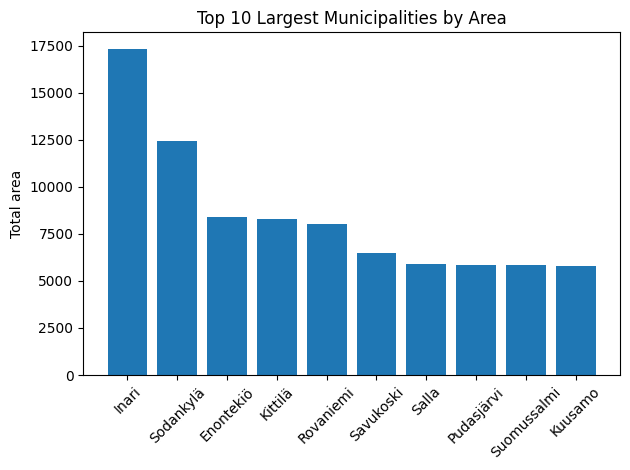

In [51]:
largest_cities = df.sort_values(by="totalarea", ascending=False).head(10)
plt.bar(largest_cities["City"], largest_cities["totalarea"])
plt.xticks(rotation=45)
plt.title("Top 10 Largest Municipalities by Area")
plt.ylabel("Total area")
plt.tight_layout()

Top 10 Municipalities by Total Accommodation Units

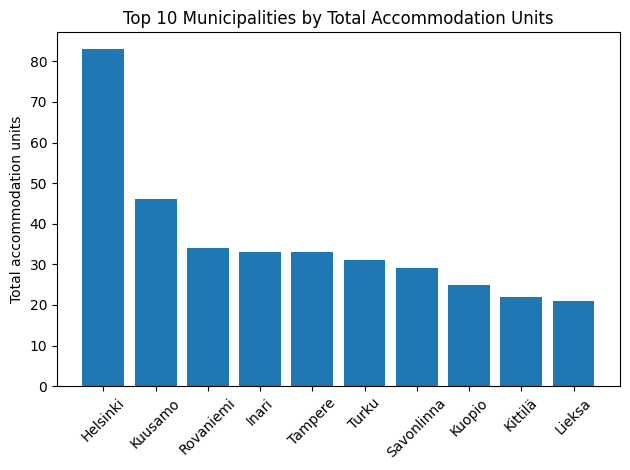

In [50]:
accommodation_capacity = df.sort_values(by="Liikkeet, lkm 2025*", ascending=False).head(10)
plt.bar(accommodation_capacity["City"], accommodation_capacity["Liikkeet, lkm 2025*"])
plt.xticks(rotation=45)
plt.title("Top 10 Municipalities by Total Accommodation Units")
plt.ylabel("Total accommodation units")
plt.tight_layout()


Top 10 Municipalities by Total Road Length

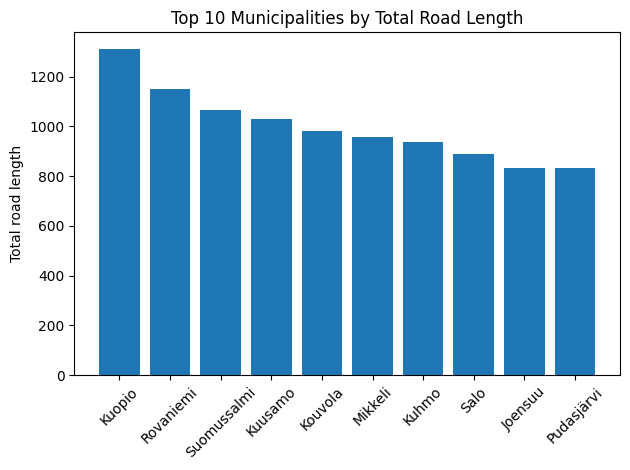

In [ ]:
road_length = df.sort_values(by="Tiepituus", ascending=False).head(10)
plt.bar(road_length["City"], road_length["Tiepituus"])
plt.xticks(rotation=45)
plt.title("Top 10 Municipalities by Total Road Length")
plt.ylabel("Total road length")
plt.tight_layout()

Scatter plot showing the relationship between road density and tourism density

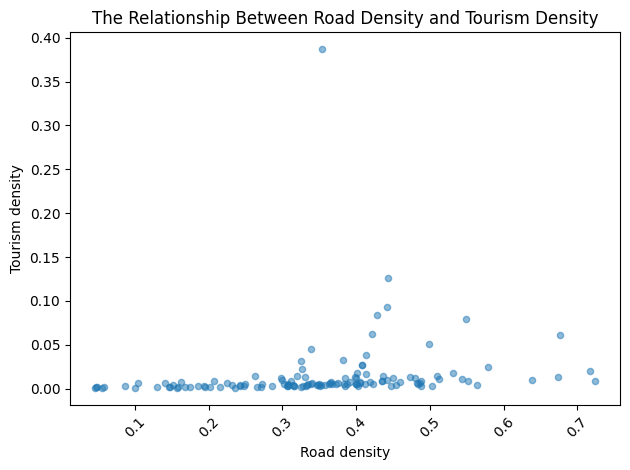

In [56]:
plt.scatter(road_dens, tourism_dens, s=20, alpha=0.5)
plt.xticks(rotation=45)
plt.title("The Relationship Between Road Density and Tourism Density")
plt.xlabel("Road density")
plt.ylabel("Tourism density")
plt.tight_layout()